In [76]:

%load_ext autoreload 
%autoreload 2
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config, get_compressed_perturbed_rep_from_mgst
from mGST.trust_region import run_riemannian_optimization
from mGST.typing import OptimizationScheduleItem, TrustRegionOptions, GradientDescentOptions, OperatorSchedule
from mGST.visualization import plot_cost_function, plot_alternating_optimization

import jax.numpy as jnp

backend = "iqmfakeapollo"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
dim = 2**4
kraus_rank = 16
state_rank = dim
povm_rank = dim

Q4_GST = create_4q_gst_config(kraus_rank=kraus_rank)

kraus_tensor_mgst, kraus_mgst, povm_mgst, state_mgst, prob_matrix, indices_list = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)


2025-10-07 19:24:32,004 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-10-07 19:24:32,443 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-10-07 19:24:32,443 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-07 19:24:32,850 - stevedore.extension - ERROR - Could not load 'ibm_backend': module 'pydantic._internal._typing_extra' has no attribute 'merge_cls_and_parent_ns'
2025-10-07 19:24:32,852 - stevedore.extension - ERROR - Could not load 'ibm_dynamic_circuits': module 'pydantic._internal._typing_extra' has no attribute 'merge_cls_and_parent_ns'
2025-10-07 19:24:32,854 - stevedore.extension - ERROR - Could not load 'ibm_fractional': module 'pydantic._internal._typing_extra' has no attribute 'merge_cls_and_parent_ns'
2025-10-07 19:24:32,857 - stevedore.extension - ERROR - Could n

In [7]:
kraus_tensor_mgst.shape, povm_mgst.shape, state_mgst.shape

((9, 16, 16, 16), (16, 256), (256,))

In [13]:
# Kraus is already perturbed
kraus_tensor_init_jax = jnp.array(kraus_tensor_mgst)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst, state_mgst)

init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(kraus_tensor_init_jax, povm_psd_init_jax, state_psd_init_jax, **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial cost value: 0.0003937179910484776


In [20]:
num_iterations = 10

tr_schedule = OperatorSchedule.default(num_iterations, TrustRegionOptions(verbose=True))
gds_schedule = OperatorSchedule.default(num_iterations, GradientDescentOptions(ls_max_iter=50))

optimization_schedule = {
    "kraus": tr_schedule,
    "povm": gds_schedule,
    "state": gds_schedule
}

In [21]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations,
    optimization_schedule=optimization_schedule,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-9]: TrustRegionOptions
povm: Schedule:
  [0-9]: GradientDescentOptions
state: Schedule:
  [0-9]: GradientDescentOptions
GDS started for operator: povm 🚀.
TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 3.935083e-04. |r∇f(x)|: 4.899755e-04. Radius: 1.00e-01
TR Iteration: 1. f(x): 3.671482e-04. |r∇f(x)|: 5.704486e-04. Radius: 2.00e-01
TR Iteration: 2. f(x): 2.896843e-04. |r∇f(x)|: 7.473482e-04. Radius: 4.00e-01
TR Iteration: 3. f(x): 1.558483e-04. |r∇f(x)|: 5.069885e-04. Radius: 4.00e-01
TR Iteration: 4. f(x): 1.124044e-04. |r∇f(x)|: 2.716449e-04. Radius: 8.00e-01
TR Iteration: 5. f(x): 1.053813e-04. |r∇f(x)|: 4.212038e-04. Radius: 2.00e-01
TR Iteration: 6. f(x): 7.006807e-05. |r∇f(x)|: 6.194645e-05. Radius: 4.00e-01
TR Iteration: 7. f(x): 6.523977e-05. |r∇f(x)|: 1.242101e-04. Radius: 4.00e-01
TR Iteration: 8. f(x): 5.956529e-05. |r∇f(x)|: 3.789378e-05. Radius: 4.00e-01
TR Iteration: 9. f(x

capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.


In [25]:
kraus_tr_cost_fn_list = [
    3.935083e-04,
    3.671482e-04,
    2.896843e-04,
    1.558483e-04,
    1.124044e-04,
    1.053813e-04,
    7.006807e-05,
    6.523977e-05,
    5.956529e-05,
    5.778590e-05,
    5.671141e-05,
    5.604164e-05,
    5.539209e-05,
    5.481213e-05,
    5.440269e-05,
    5.413473e-05,
    5.391843e-05
]

In [26]:
cost_fn_history_appended = [initial_cost_value] + kraus_tr_cost_fn_list

In [ ]:
optimization_schedule_all_gds = {
    "kraus": gds_schedule,
    "povm": gds_schedule,
    "state": gds_schedule
}

In [29]:
optimized_operators_all_gds, cost_fn_history_all_gds = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations,
    optimization_schedule=optimization_schedule_all_gds,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-9]: GradientDescentOptions
povm: Schedule:
  [0-9]: GradientDescentOptions
state: Schedule:
  [0-9]: GradientDescentOptions
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 1/10. f(x): 3.870386e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 2/10. f(x): 3.824973e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 3/10. f(x): 3.784292e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 4/10. f(x): 3.744558e-04.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
G

In [36]:
num_iterations_all_tr = 2
tr_schedule_verbose = OperatorSchedule.default(num_iterations_all_tr, TrustRegionOptions(num_iterations=10, verbose=True, verbose_cg=True, num_iterations_cg=5))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}

In [38]:
optimized_operators_all_tr_short, cost_fn_history_all_tr_short = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_all_tr,
    optimization_schedule=optimization_schedule_all_tr,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization schedule: 
kraus: Schedule:
  [0-1]: TrustRegionOptions
povm: Schedule:
  [0-1]: TrustRegionOptions
state: Schedule:
  [0-1]: TrustRegionOptions
TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 3.937180e-04. |r∇f(x)|: 9.215167e-05. Radius: 1.00e-01
TCG finished after: 2/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 3.866943e-04. |r∇f(x)|: 7.253792e-05. Radius: 2.00e-01
TCG finished after: 2/5 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 3.839685e-04. |r∇f(x)|: 5.668619e-05. Radius: 4.00e-01
TCG finished after: 2/5 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 3. f(x): 3.677726e-04. |r∇f(x)|: 1.488142e-04. Radius: 4.00e-01
TCG finished after: 2/5 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------

In [42]:
cost_fn_history_all_tr_short_appended = [initial_cost_value] + cost_fn_history_all_tr_short

In [86]:
cost_fn_history_all_tr_detailed = [
    3.937180e-04, # start (unoptimized) - povm start
    3.866943e-04,
    3.839685e-04,
    3.677726e-04,
    3.677726e-04,
    3.600297e-04,
    3.552821e-04,
    3.482875e-04,
    3.469862e-04,
    3.382768e-04,
    3.216642e-04, # povm: end
    # 3.216642e-04, # kraus: start
    3.003958e-04,
    2.463915e-04,
    1.892129e-04,
    1.369632e-04,
    1.169368e-04,
    8.981661e-05,
    8.148602e-05,
    7.634726e-05,
    7.257834e-05,
    6.969371e-05, # kraus: end
    # 6.969371e-05, # state: start
    6.932387e-05, # state: end
    # 6.932387e-05, # povm: start
    6.420320e-05,
    6.191373e-05,
    6.191373e-05,
    6.051235e-05,
    5.956977e-05,
    5.806086e-05,
    5.776766e-05,
    5.667053e-05,
    5.599748e-05,
    5.563656e-05, # povm: end
    # 5.563656e-05, # kraus: start
    5.204869e-05,
    5.065540e-05,
    4.986451e-05,
    4.928563e-05,
    4.879007e-05,
    4.835945e-05,
    4.797644e-05,
    4.763513e-05,
    4.732711e-05,
    4.704901e-05, # kraus: end
    # 4.704901e-05, # state: start
    4.702436e-05, # state: end
    # 4.702436e-05 # Full END
]

In [87]:
data_operator_map = [
    ("povm", 10), ("kraus", 10), ("state", 1), ("povm", 10), ("kraus", 10), ("state", 1),
] # add an extra 1 in the beginning in POVM for initial cost value

# length of the sequences defined by data operator map
length_of_sequences = sum([length for _, length in data_operator_map])

print("Length of sequences:", length_of_sequences)
print(len(cost_fn_history_all_tr_detailed))

Length of sequences: 42
43


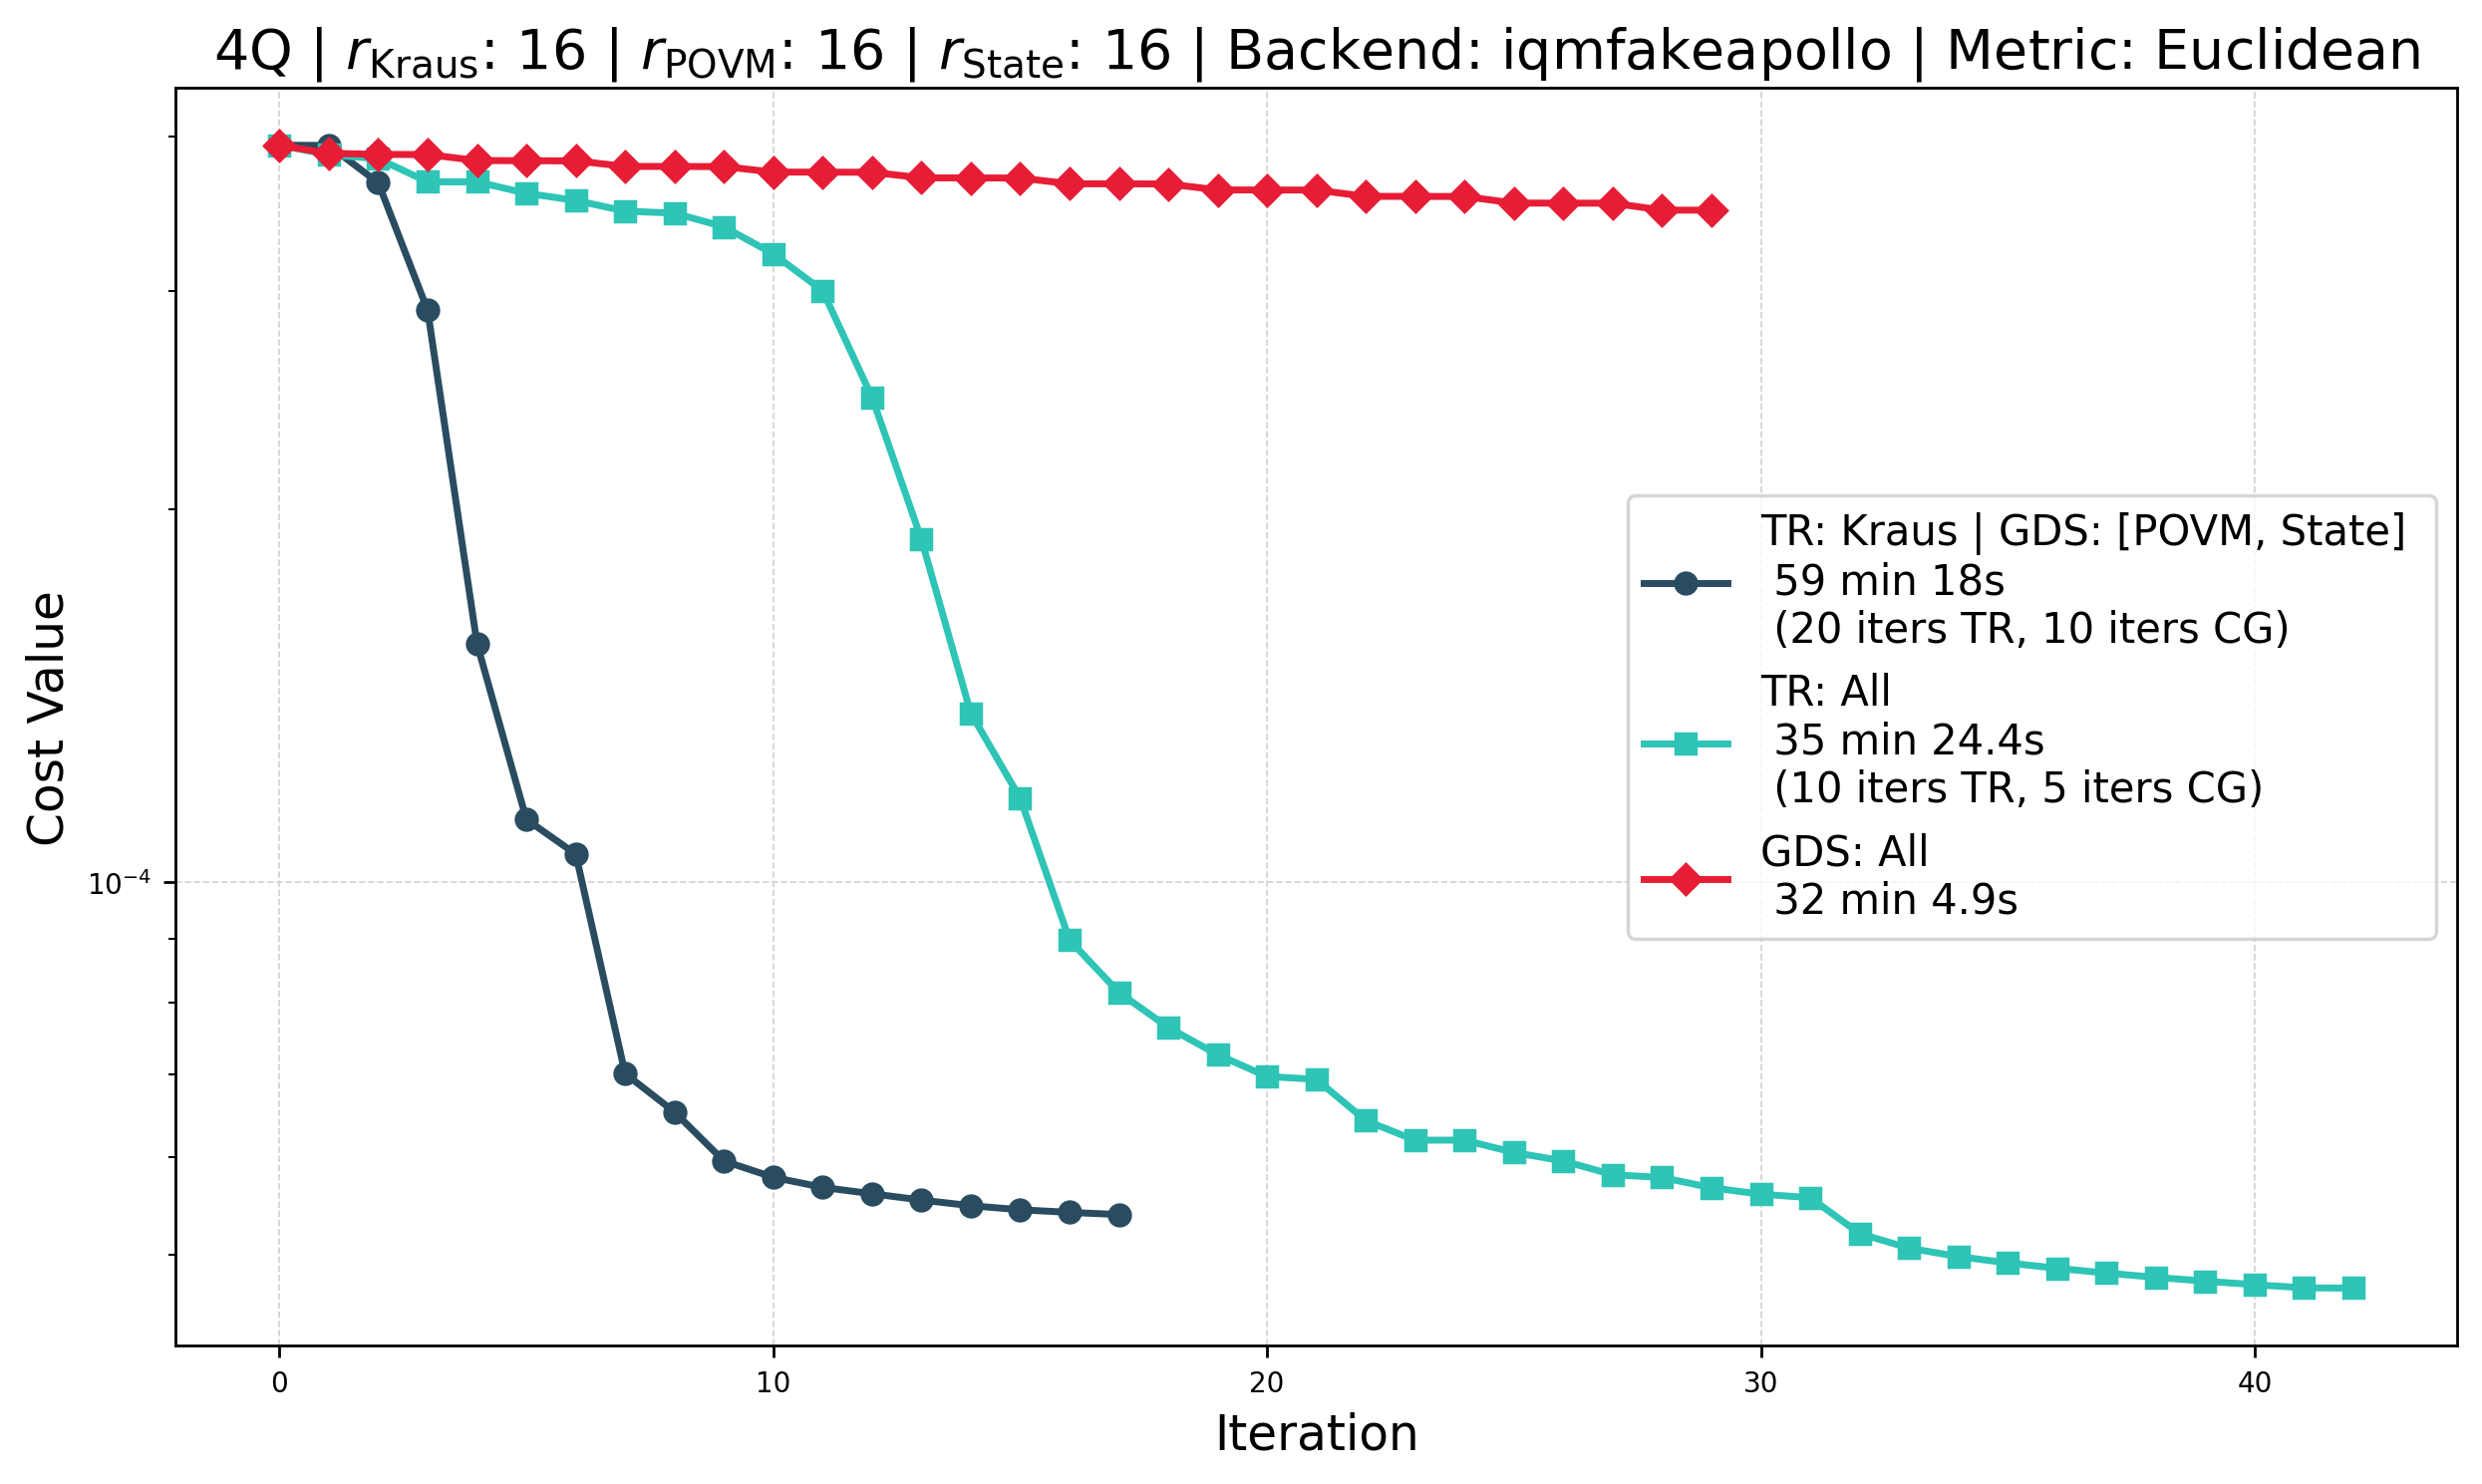

In [88]:
cost_fn_lists = [
    cost_fn_history_appended,
    cost_fn_history_all_tr_detailed,
    cost_fn_history_all_gds,
    # cost_fn_history_all_tr_short_appended
]

labels = [
    "TR: Kraus | GDS: [POVM, State] \n 59 min 18s \n (20 iters TR, 10 iters CG)",
    "TR: All \n 35 min 24.4s \n (10 iters TR, 5 iters CG)",
    "GDS: All \n 32 min 4.9s ",
]

title = rf"4Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: {backend} | Metric: Euclidean"

plot_cost_function(cost_fn_lists, title=title, labels=labels)

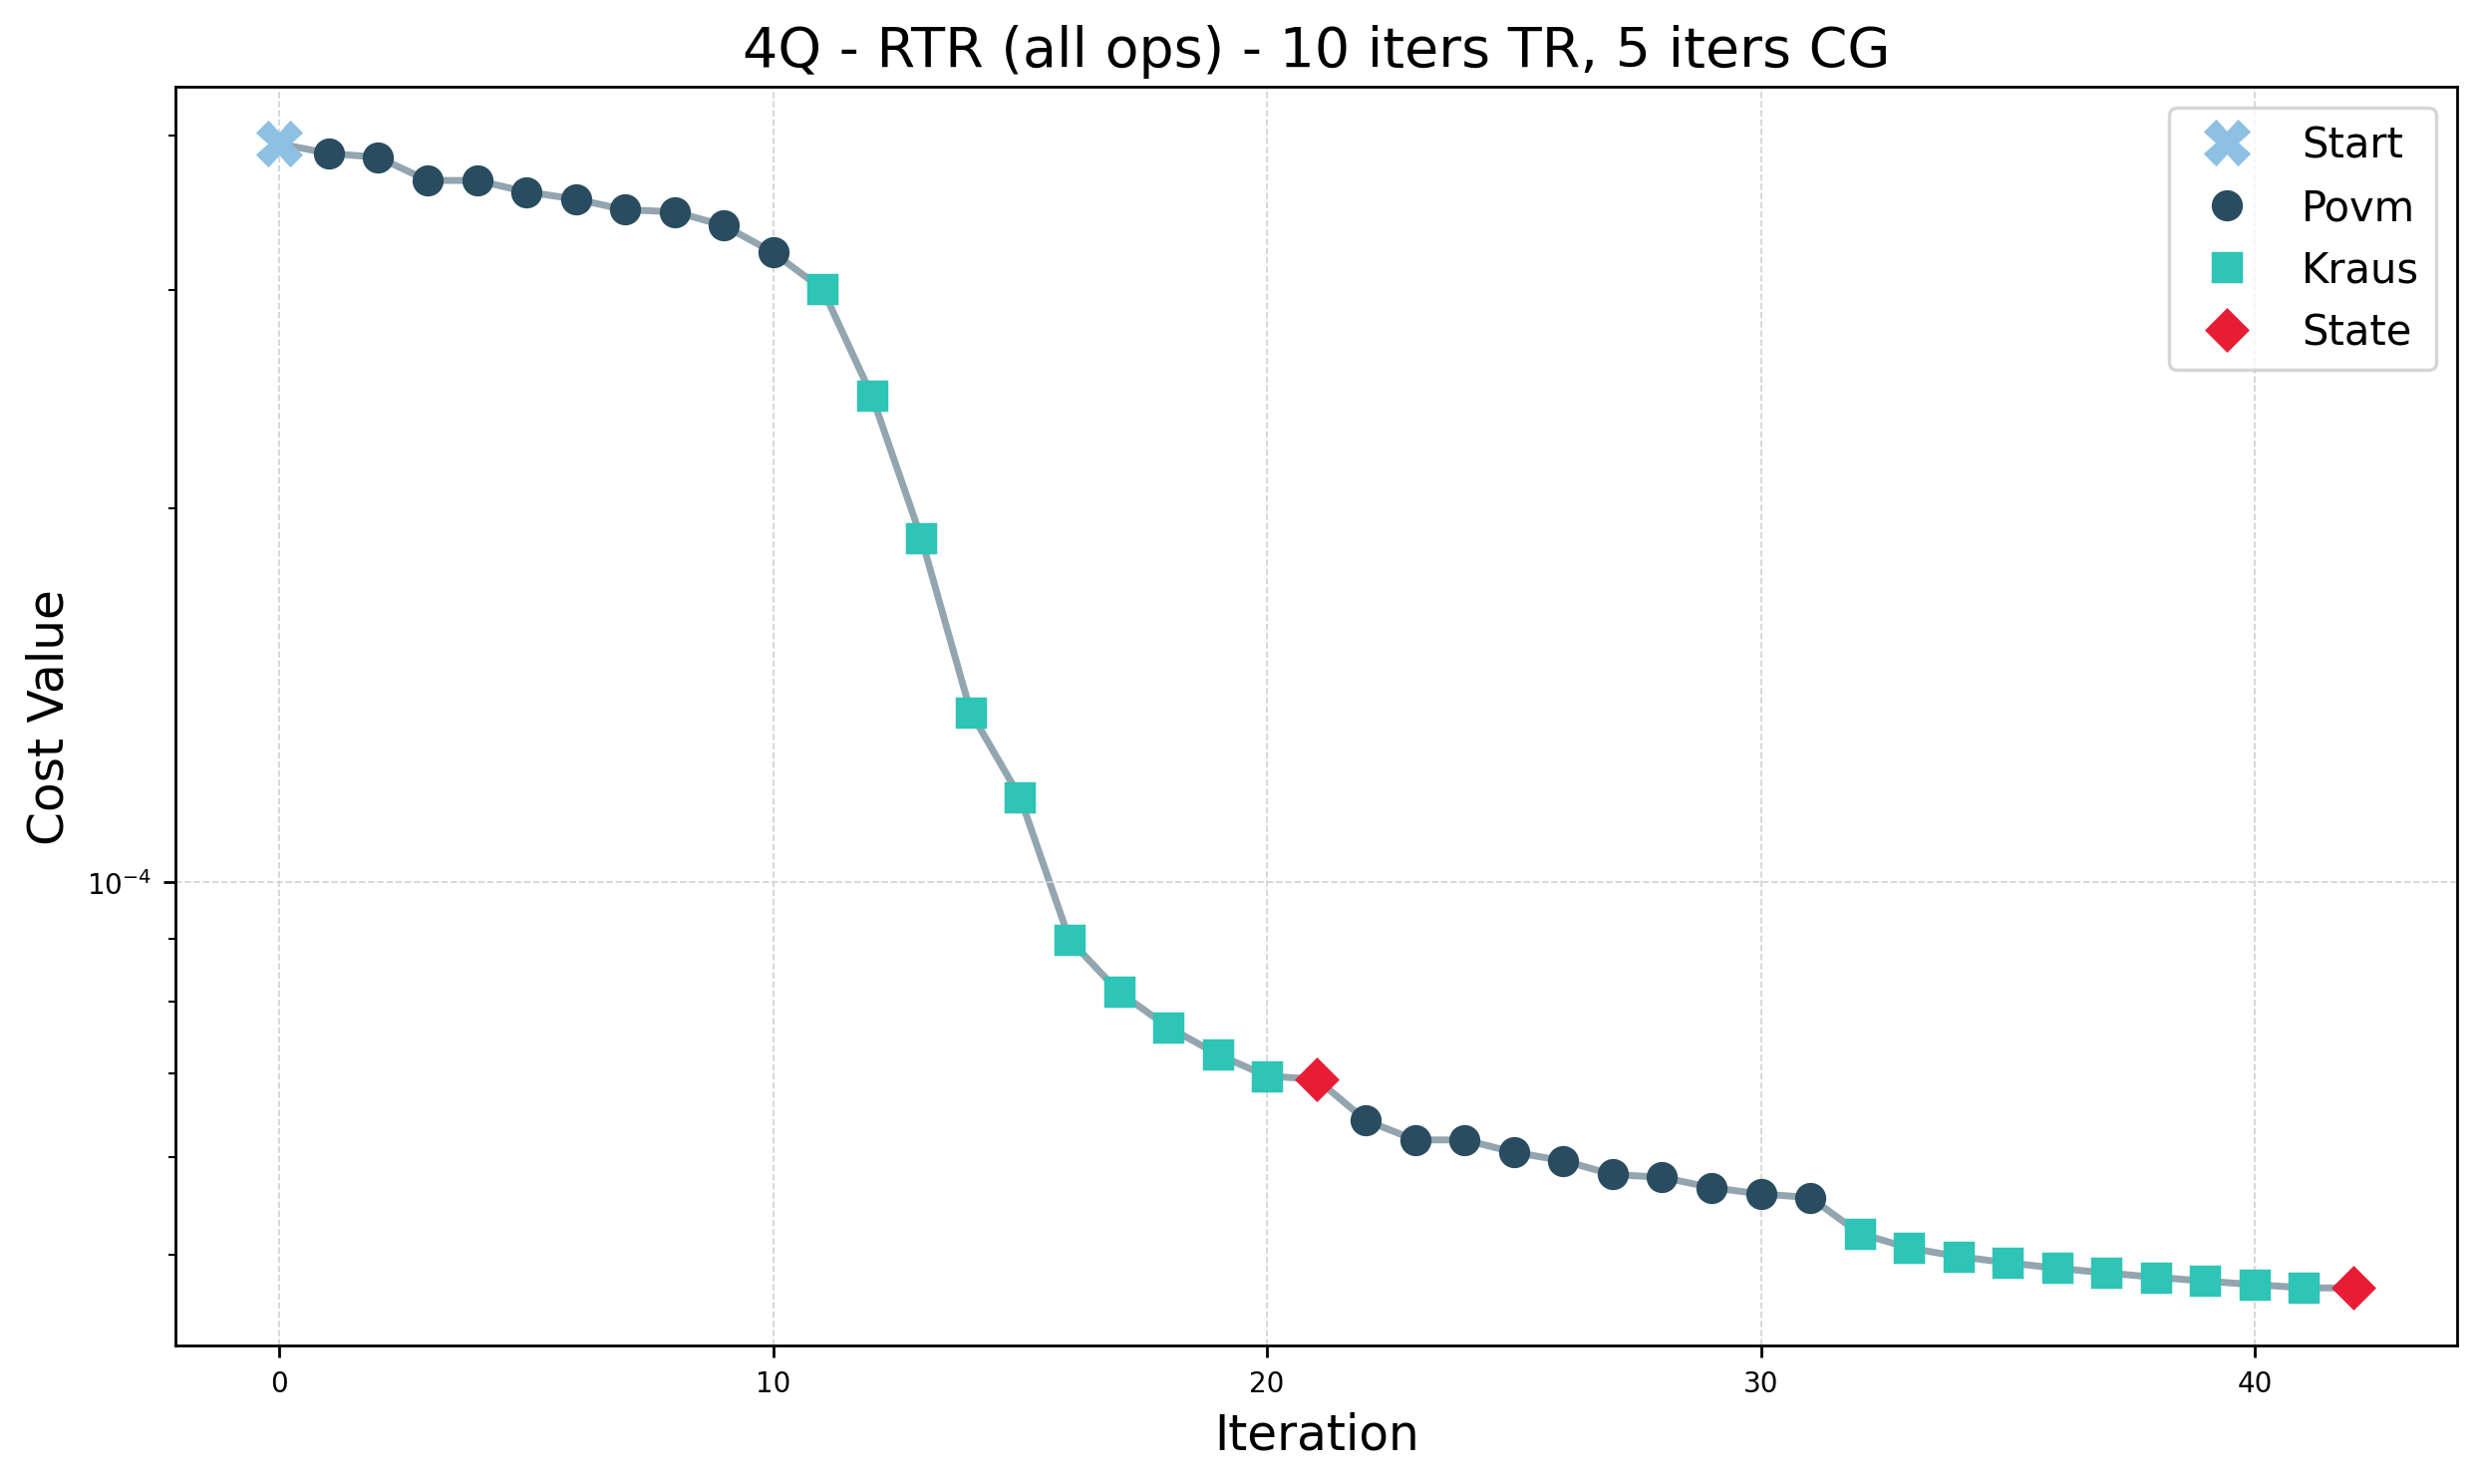

In [102]:
plot_alternating_optimization(
    cost_array=cost_fn_history_all_tr_detailed,
    data_operator_map=data_operator_map,
    title="4Q - RTR (all ops) - 10 iters TR, 5 iters CG"
)